In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [13]:
df = pd.read_csv(r"claim_dirty.csv")
df.head()

,claim_id,event_id,member_id,employee_code,member_name,gender,relation,age,age_band,company_name,...,claim_received_date,processed_date,payment_date,processing_tat_days,payment_tat_days,is_fraud_flag,fraud_score,fraud_reason,insurer,tpa_name
0,200001,300001,5003895,emp_SPIL11111,Rohit Sinha,Male,Self,50,36-50,Sunrise Pharma Industries Ltd,...,2025-08-10,2025-08-29,2025-09-05,19,7.0,0,14,NaN,The New India Assurance Co. Ltd,Medi Assist Insurance TPA Pvt. Ltd.
1,200002,300002,5012786,emp_DKTL13624,Ashok Patel,Male,Self,24,19-35,Deccan Textiles Ltd,...,2025-09-21,2025-09-28,2025-10-03,7,5.0,0,12,NaN,The New India Assurance Co. Ltd,Medi Assist Insurance TPA Pvt. Ltd.
2,200003,300003,5005271,emp_SPIL11497,Rakesh Tiwari,Male,Son,8,0-18,Sunrise Pharma Industries Ltd,...,2025-05-02,2025-05-12,NaN,10,NaN,0,36,Claim shortly after policy start,The New India Assurance Co. Ltd,Medi Assist Insurance TPA Pvt. Ltd.
3,200004,300004,5005271,emp_SPIL11497,Rakesh Tiwari,Male,Son,8,0-18,Sunrise Pharma Industries Ltd,...,2025-06-14,2025-06-28,2025-06-29,14,1.0,0,2,NaN,The New India Assurance Co. Ltd,Medi Assist Insurance TPA Pvt. Ltd.
4,200005,300005,5000400,emp_BSPL10109,Lata Nair,Female,Spouse,53,51-60,Bharat Steel & Power Ltd,...,2025-09-24,2025-10-14,2025-10-21,20,7.0,0,35,Inflated bill amount,The New India Assurance Co. Ltd,Medi Assist Insurance TPA Pvt. Ltd.


In [14]:
df.info()
df.describe()
df.shape



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6232 entries, 0 to 6231
Data columns (total 44 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   claim_id              6232 non-null   int64  
 1   event_id              6232 non-null   int64  
 2   member_id             6232 non-null   int64  
 3   employee_code         6232 non-null   object 
 4   member_name           6232 non-null   object 
 5   gender                6232 non-null   object 
 6   relation              6232 non-null   object 
 7   age                   6232 non-null   int64  
 8   age_band              6232 non-null   object 
 9   company_name          6232 non-null   object 
 10  grade                 6232 non-null   object 
 11  sum_insured           6232 non-null   int64  
 12  policy_number         6232 non-null   object 
 13  policy_start          6232 non-null   object 
 14  policy_end            6232 non-null   object 
 15  claim_type           

(6232, 44)

In [15]:
# Fix gender
gender_map = {'M':'Male','F':'Female','male':'Male',
              'female':'Female','MALE':'Male','FEMALE':'Female'}
df['gender'] = df['gender'].replace(gender_map)

In [16]:
# Remove duplicates
df.drop_duplicates(subset=['claim_id'], keep='first', inplace=True)

In [17]:
# Fix amounts
df['billed_amount'] = df['billed_amount'].fillna(df['billed_amount'].median())
df.loc[df['approved_amount']>df['billed_amount'], 'approved_amount'] = df['billed_amount']

In [18]:
# Fix LOS
df.loc[df['length_of_stay']<0, 'length_of_stay'] = 0

In [19]:
# Standardise claim type
df['claim_type'] = df['claim_type'].str.strip().str.title()

In [20]:
# Fix dates
df['date_of_admission'] = pd.to_datetime(
    df['date_of_admission'], dayfirst=False, errors='coerce')

In [21]:
df.to_csv(r'claim_clean.csv', index=False)

In [22]:
df = pd.read_csv(r'claim_clean.csv')
df.head()

,claim_id,event_id,member_id,employee_code,member_name,gender,relation,age,age_band,company_name,...,claim_received_date,processed_date,payment_date,processing_tat_days,payment_tat_days,is_fraud_flag,fraud_score,fraud_reason,insurer,tpa_name
0,200001,300001,5003895,emp_SPIL11111,Rohit Sinha,Male,Self,50,36-50,Sunrise Pharma Industries Ltd,...,2025-08-10,2025-08-29,2025-09-05,19,7.0,0,14,NaN,The New India Assurance Co. Ltd,Medi Assist Insurance TPA Pvt. Ltd.
1,200002,300002,5012786,emp_DKTL13624,Ashok Patel,Male,Self,24,19-35,Deccan Textiles Ltd,...,2025-09-21,2025-09-28,2025-10-03,7,5.0,0,12,NaN,The New India Assurance Co. Ltd,Medi Assist Insurance TPA Pvt. Ltd.
2,200003,300003,5005271,emp_SPIL11497,Rakesh Tiwari,Male,Son,8,0-18,Sunrise Pharma Industries Ltd,...,2025-05-02,2025-05-12,NaN,10,NaN,0,36,Claim shortly after policy start,The New India Assurance Co. Ltd,Medi Assist Insurance TPA Pvt. Ltd.
3,200004,300004,5005271,emp_SPIL11497,Rakesh Tiwari,Male,Son,8,0-18,Sunrise Pharma Industries Ltd,...,2025-06-14,2025-06-28,2025-06-29,14,1.0,0,2,NaN,The New India Assurance Co. Ltd,Medi Assist Insurance TPA Pvt. Ltd.
4,200005,300005,5000400,emp_BSPL10109,Lata Nair,Female,Spouse,53,51-60,Bharat Steel & Power Ltd,...,2025-09-24,2025-10-14,2025-10-21,20,7.0,0,35,Inflated bill amount,The New India Assurance Co. Ltd,Medi Assist Insurance TPA Pvt. Ltd.


In [23]:
# Fraud by company
fraud_comp = df.groupby('company_name').agg(
    total=('claim_id','count'),
    frauds=('is_fraud_flag','sum'),
    total_billed=('billed_amount','sum')
).assign(fraud_rate=lambda x: x['frauds']/x['total']*100).round(2)
print(fraud_comp)

                               total  frauds  total_billed  fraud_rate
company_name                                                          
Bharat Steel & Power Ltd        1806      46   259808788.0        2.55
Deccan Textiles Ltd              775      30   117288627.0        3.87
IndoAgro Foods Pvt Ltd          1118      48   156546711.0        4.29
Narmada Infrastructure Corp      966      35   151377817.0        3.62
Sunrise Pharma Industries Ltd   1505      60   205531259.0        3.99


In [24]:
# Utilisation ratio
df['utilisation_ratio'] = df['billed_amount'] / df['sum_insured']


In [25]:
# Repeat claimant detection
df_sorted = df.sort_values(['member_id','date_of_admission'])
df_sorted['prev_date'] = df_sorted.groupby('member_id')['date_of_admission'].shift()
df_sorted['days_since_last'] = (
    pd.to_datetime(df_sorted['date_of_admission'])
    - pd.to_datetime(df_sorted['prev_date'])).dt.days
repeat = df_sorted[df_sorted['days_since_last'] < 60]
print(f"Repeat claimants (within 60 days): {len(repeat)}")

Repeat claimants (within 60 days): 833


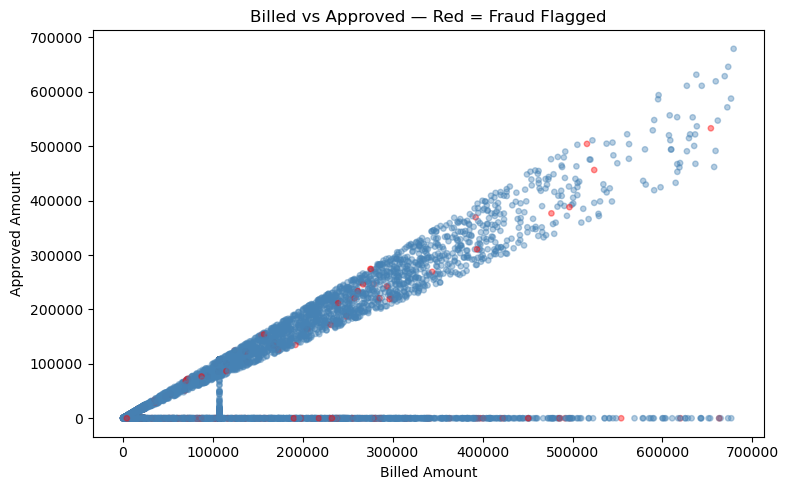

In [26]:
# Scatter: billed vs approved
colors = df['is_fraud_flag'].map({0:'steelblue', 1:'red'})
plt.figure(figsize=(8,5))
plt.scatter(df['billed_amount'], df['approved_amount'],
            c=colors, alpha=0.4, s=15)
plt.xlabel('Billed Amount')
plt.ylabel('Approved Amount')
plt.title('Billed vs Approved — Red = Fraud Flagged')
plt.tight_layout()
plt.savefig('fraud_scatter.png', dpi=150)